<a href="https://colab.research.google.com/github/oleksandr-and-oleksandr/ai/blob/main/yolo_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.6 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="6PIRSS1wssLuc1O1NS8I")
project = rf.workspace("simonanastasov").project("guitar-nut-and-neck")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Guitar-nut-and-neck-3 in yolov8:: 100%|██████████| 709/709 [00:00<00:00, 9381.87it/s]


In [ ]:
import os
from pathlib import Path

DATASET_PATH = Path('/content/Guitar-nut-and-neck-3')

# Перевіряємо структуру
print("=" * 60)
print("СТРУКТУРА ДАТАСЕТУ")
print("=" * 60)

for split in ['train', 'valid', 'test']:
    img_dir = DATASET_PATH / split / 'images'
    lbl_dir = DATASET_PATH / split / 'labels'

    n_imgs = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    n_lbls = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0

    status = "✅" if n_imgs == n_lbls and n_imgs > 0 else "⚠️"
    print(f"{status} {split:6s}: {n_imgs:4d} images, {n_lbls:4d} labels")

# Дивимося data.yaml
print("\n" + "=" * 60)
print("DATA.YAML")
print("=" * 60)
with open(DATASET_PATH / 'data.yaml') as f:
    print(f.read())

СТРУКТУРА ДАТАСЕТУ
✅ train :  309 images,  309 labels
✅ valid :   28 images,   28 labels
✅ test  :   15 images,   15 labels

DATA.YAML
names:
- neck
- nut
nc: 2
roboflow:
  license: CC BY 4.0
  project: guitar-nut-and-neck
  url: https://universe.roboflow.com/simonanastasov/guitar-nut-and-neck/dataset/3
  version: 3
  workspace: simonanastasov
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
import yaml

data_yaml_path = DATASET_PATH / 'data.yaml'

# Читаємо
with open(data_yaml_path) as f:
    data = yaml.safe_load(f)

# Виправляємо на абсолютні шляхи
data['path'] = str(DATASET_PATH)
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

# Зберігаємо
with open(data_yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("✅ data.yaml оновлено")
with open(data_yaml_path) as f:
    print(f.read())

✅ data.yaml оновлено
names:
- neck
- nut
nc: 2
path: /content/Guitar-nut-and-neck-3
roboflow:
  license: CC BY 4.0
  project: guitar-nut-and-neck
  url: https://universe.roboflow.com/simonanastasov/guitar-nut-and-neck/dataset/3
  version: 3
  workspace: simonanastasov
test: test/images
train: train/images
val: valid/images



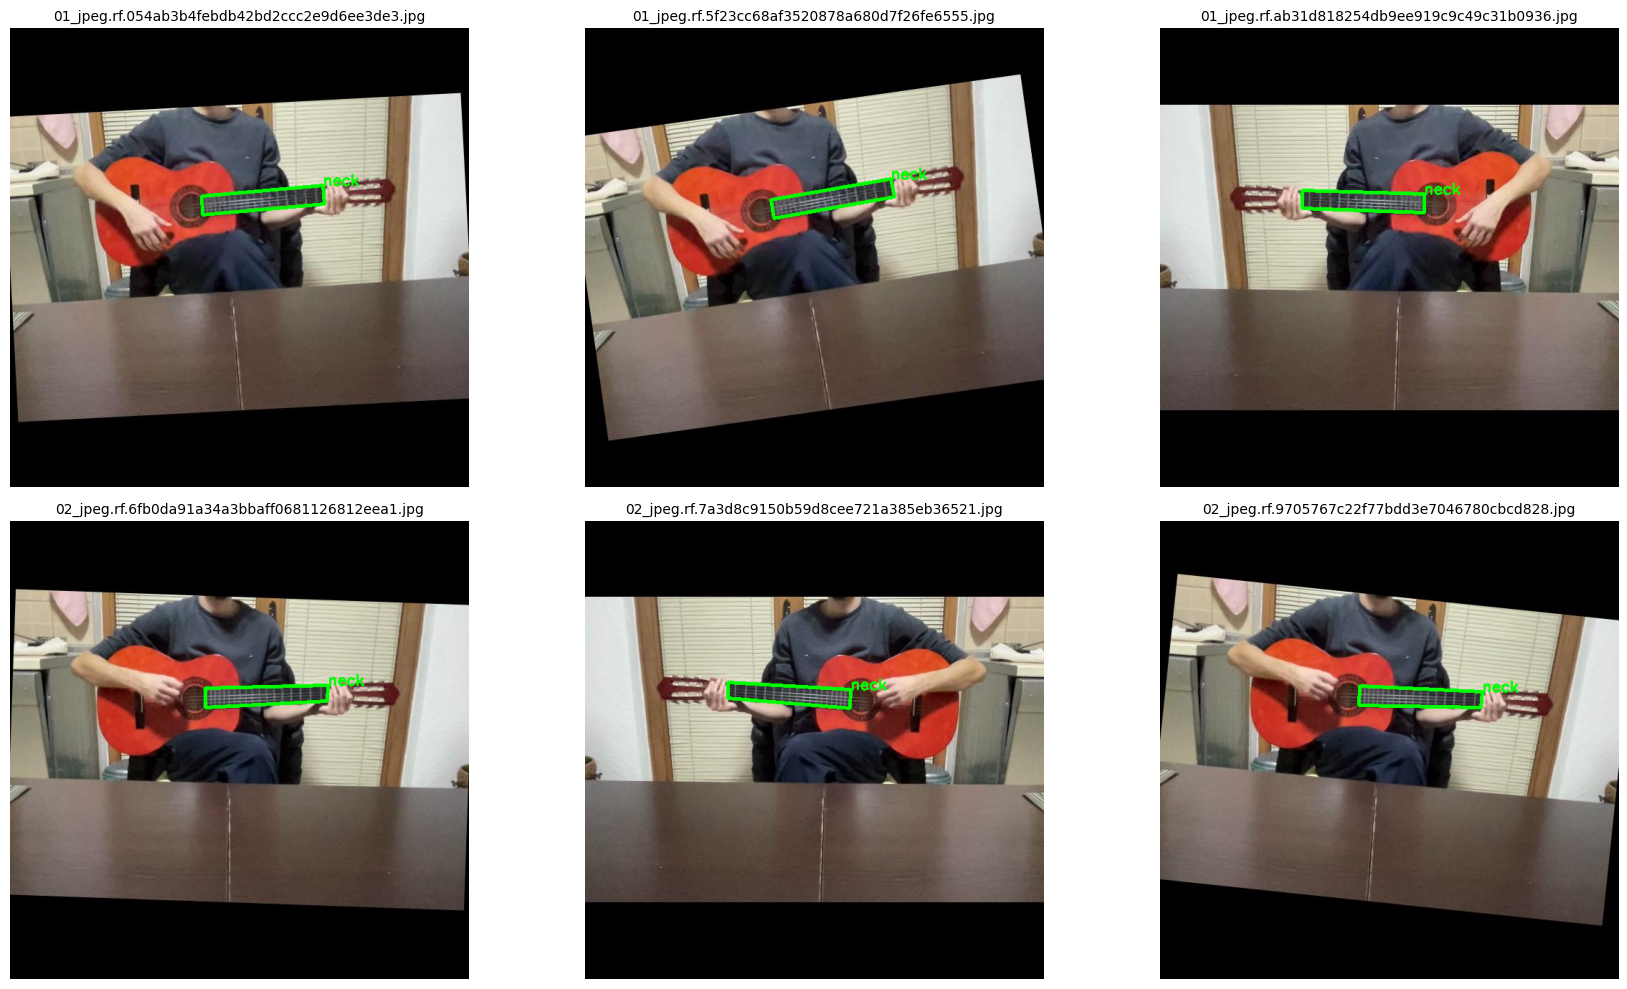

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_sample(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    colors = [(0, 255, 0), (255, 0, 0)]  # зелений neck, червоний nut
    names = ['neck', 'nut']

    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                coords = list(map(float, parts[1:]))
                pts = np.array([[int(coords[i]*w), int(coords[i+1]*h)]
                               for i in range(0, len(coords), 2)], dtype=np.int32)
                cv2.polylines(img, [pts], True, colors[cls], 3)
                cv2.putText(img, names[cls], tuple(pts[0]),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, colors[cls], 2)
    return img

# Показуємо 6 прикладів
train_imgs = sorted((DATASET_PATH / 'train/images').glob('*'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_p in zip(axes.flat, train_imgs):
    lbl_p = DATASET_PATH / 'train/labels' / (img_p.stem + '.txt')
    ax.imshow(visualize_sample(img_p, lbl_p))
    ax.set_title(img_p.name, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/dataset_preview.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
from ultralytics import YOLO

# Завантажуємо передтреновану модель
model = YOLO('yolov8s-seg.pt')  # small — баланс швидкість/точність

results = model.train(
    # === ОСНОВНЕ ===
    data=str(DATASET_PATH / 'data.yaml'),
    epochs=80,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,  # відтворюваність

    # === ЗБЕРЕЖЕННЯ ===
    project='/content/runs/guitar',
    name='seg_v1',
    exist_ok=False,
    save=True,
    save_period=-1,  # тільки best і last
    plots=True,
    verbose=True,

    # === ОПТИМІЗАЦІЯ ===
    optimizer='AdamW',
    lr0=0.001,          # для AdamW менший за SGD
    lrf=0.01,           # фінальний lr = lr0 * 0.01
    patience=20,        # early stopping
    warmup_epochs=3,
    weight_decay=0.0005,

    # === АУГМЕНТАЦІЇ (важливо для малого датасету!) ===
    hsv_h=0.015,        # легкий зсув кольорів
    hsv_s=0.7,          # сильна варіація насиченості
    hsv_v=0.4,          # різна яскравість
    degrees=15,         # поворот ±15°
    translate=0.1,      # зсув ±10%
    scale=0.5,          # масштаб 0.5-1.5x
    shear=2.0,          # легкий скіс
    perspective=0.0005, # легка перспектива (корисно для грифа!)
    fliplr=0.5,         # 50% горизонтальний фліп
    flipud=0.0,         # без вертикального (гітара не перевертається)
    mosaic=1.0,         # mosaic завжди
    mixup=0.0,          # вимкнено для seg
    copy_paste=0.3,     # трохи copy-paste для seg
    close_mosaic=10,    # останні 10 епох без mosaic (чисті фото)

    # === ТЕХНІЧНЕ ===
    amp=True,           # mixed precision — швидше
    workers=2,          # для Colab 2 стабільніше за 8
    pretrained=True,    # transfer learning
    val=True,           # валідація після кожної епохи
)

print(f"\n✅ Тренування завершено!")
print(f"Результати збережено в: {results.save_dir}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Guitar-nut-and-neck-3/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True,

ФІНАЛЬНІ МЕТРИКИ
Epoch: 80
Box mAP50: 0.965
Box mAP50-95: 0.837
Mask mAP50: 0.919  ← головна метрика
Mask mAP50-95: 0.730


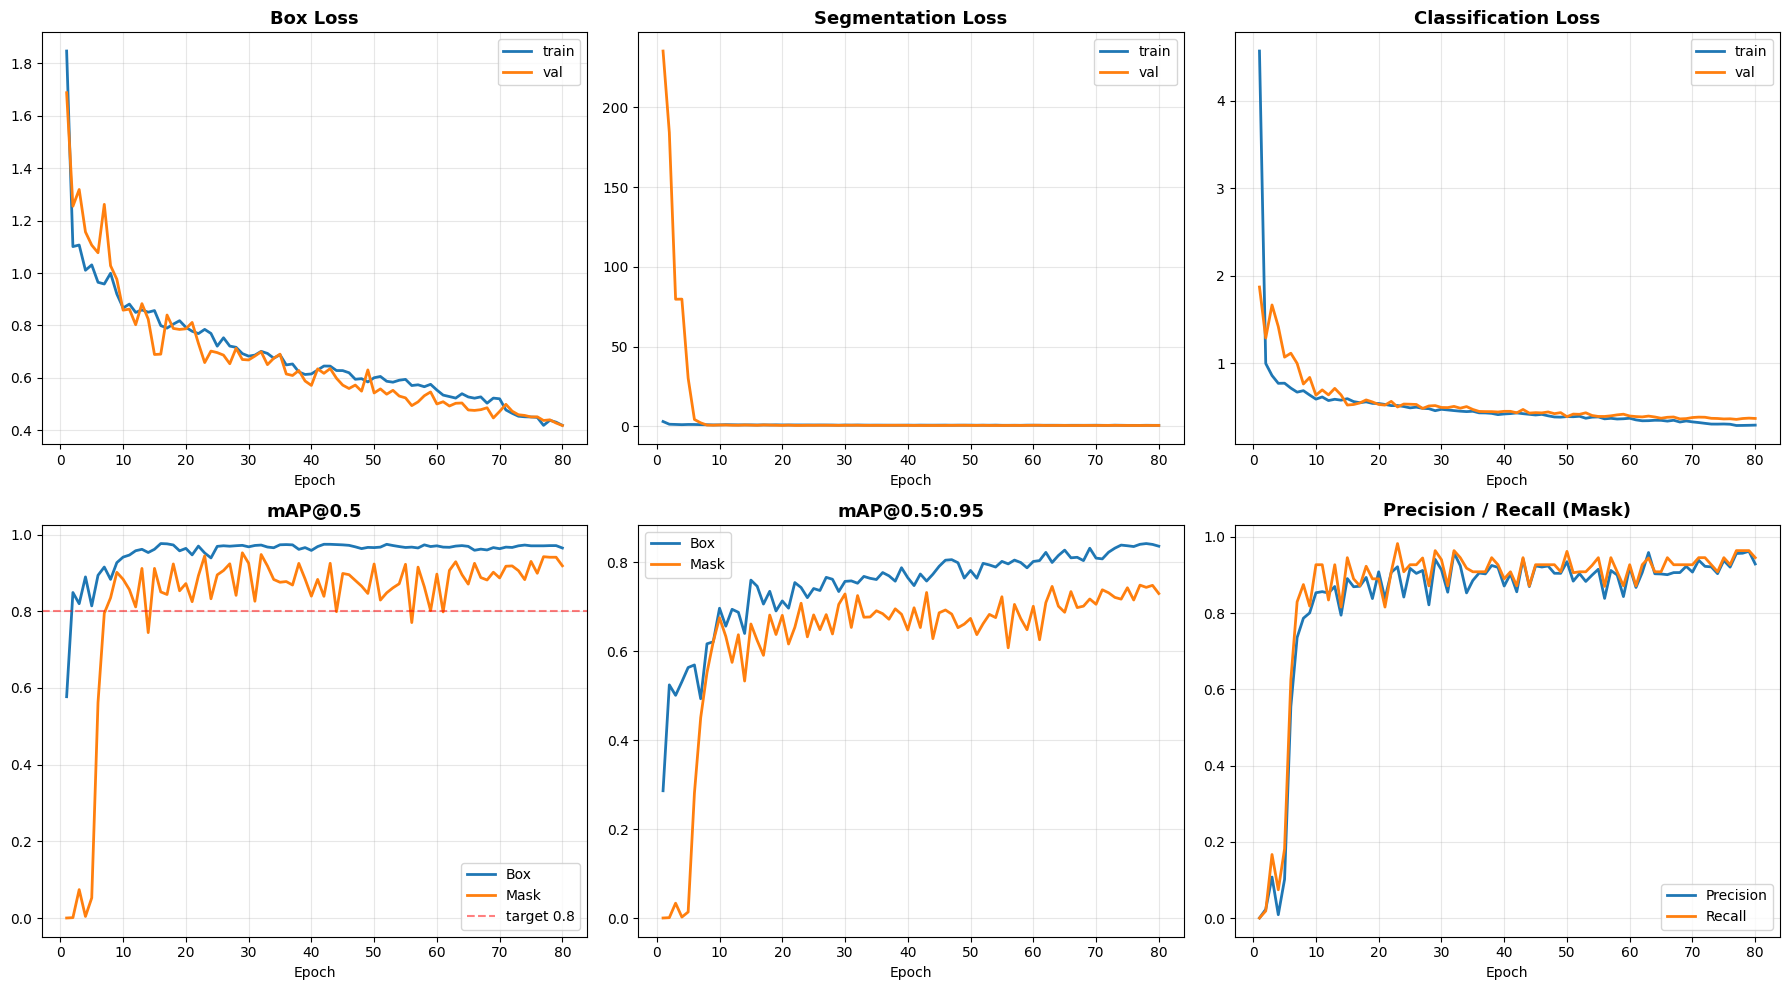


Автоматичні графіки YOLO:

results.png:


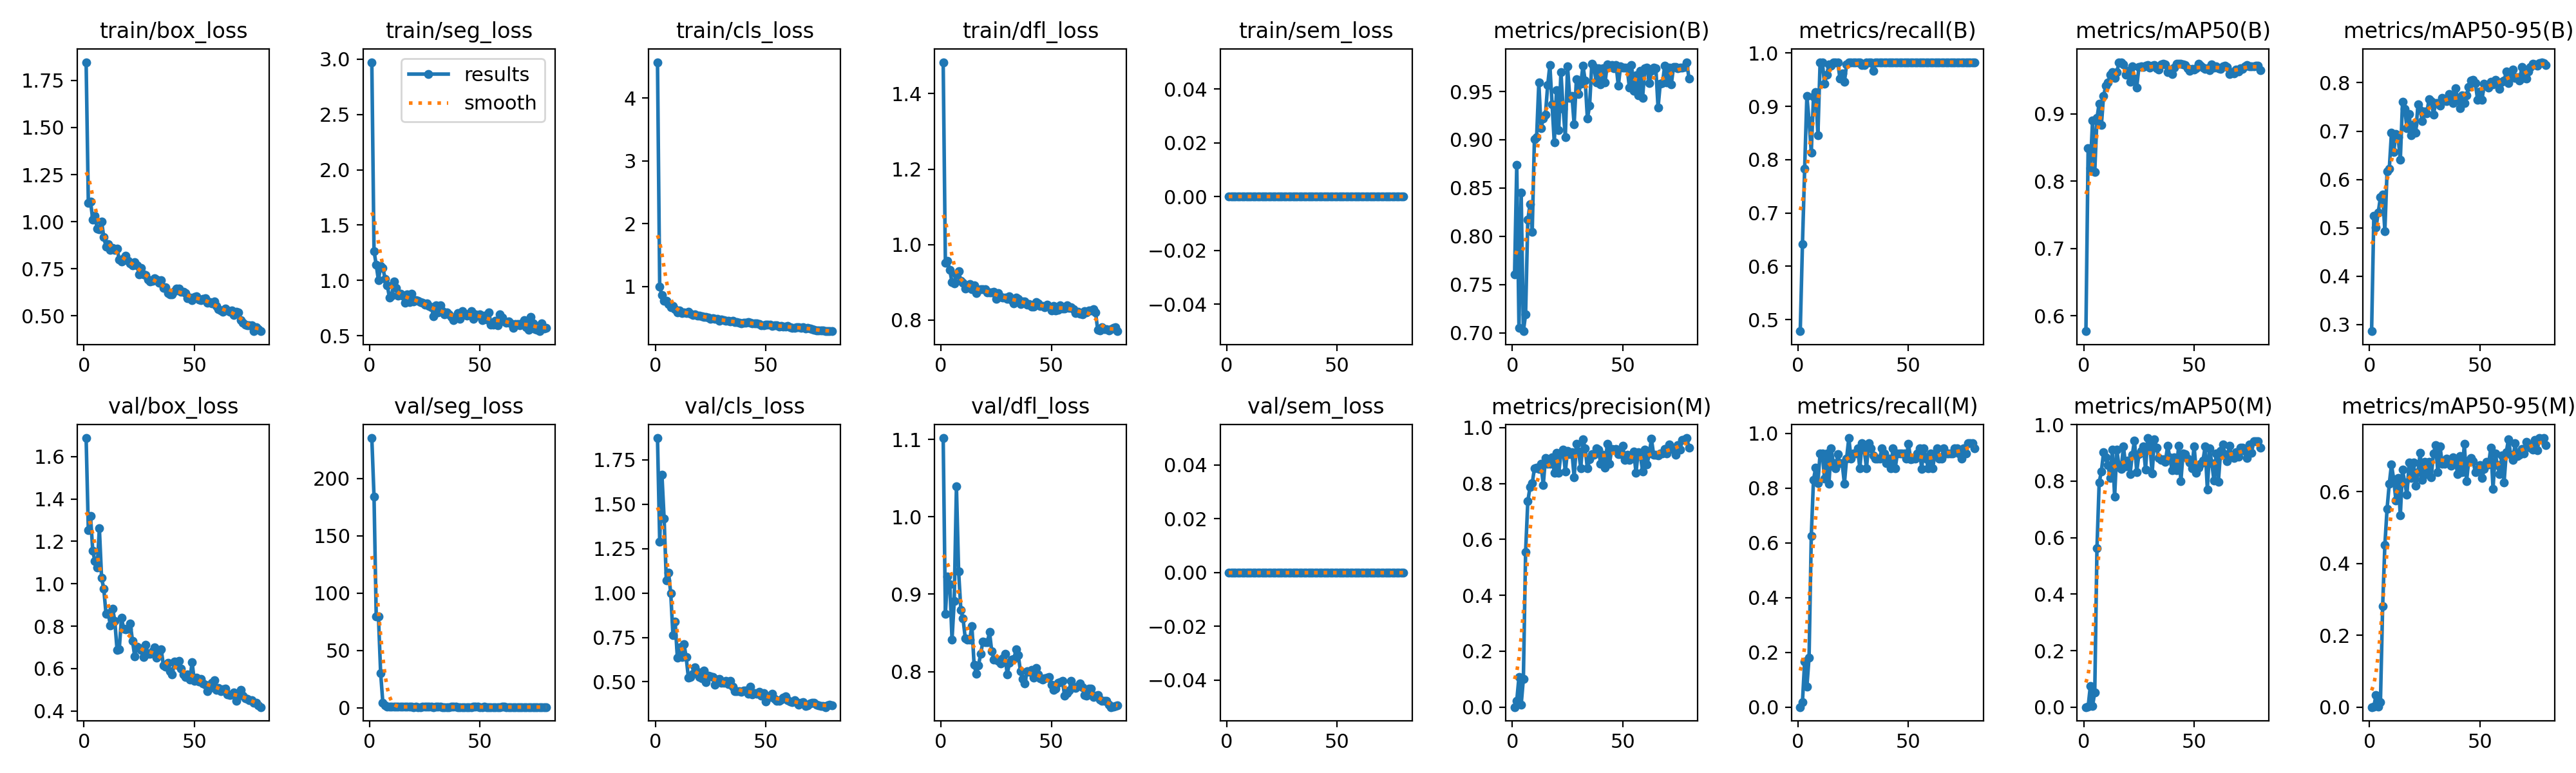


confusion_matrix.png:


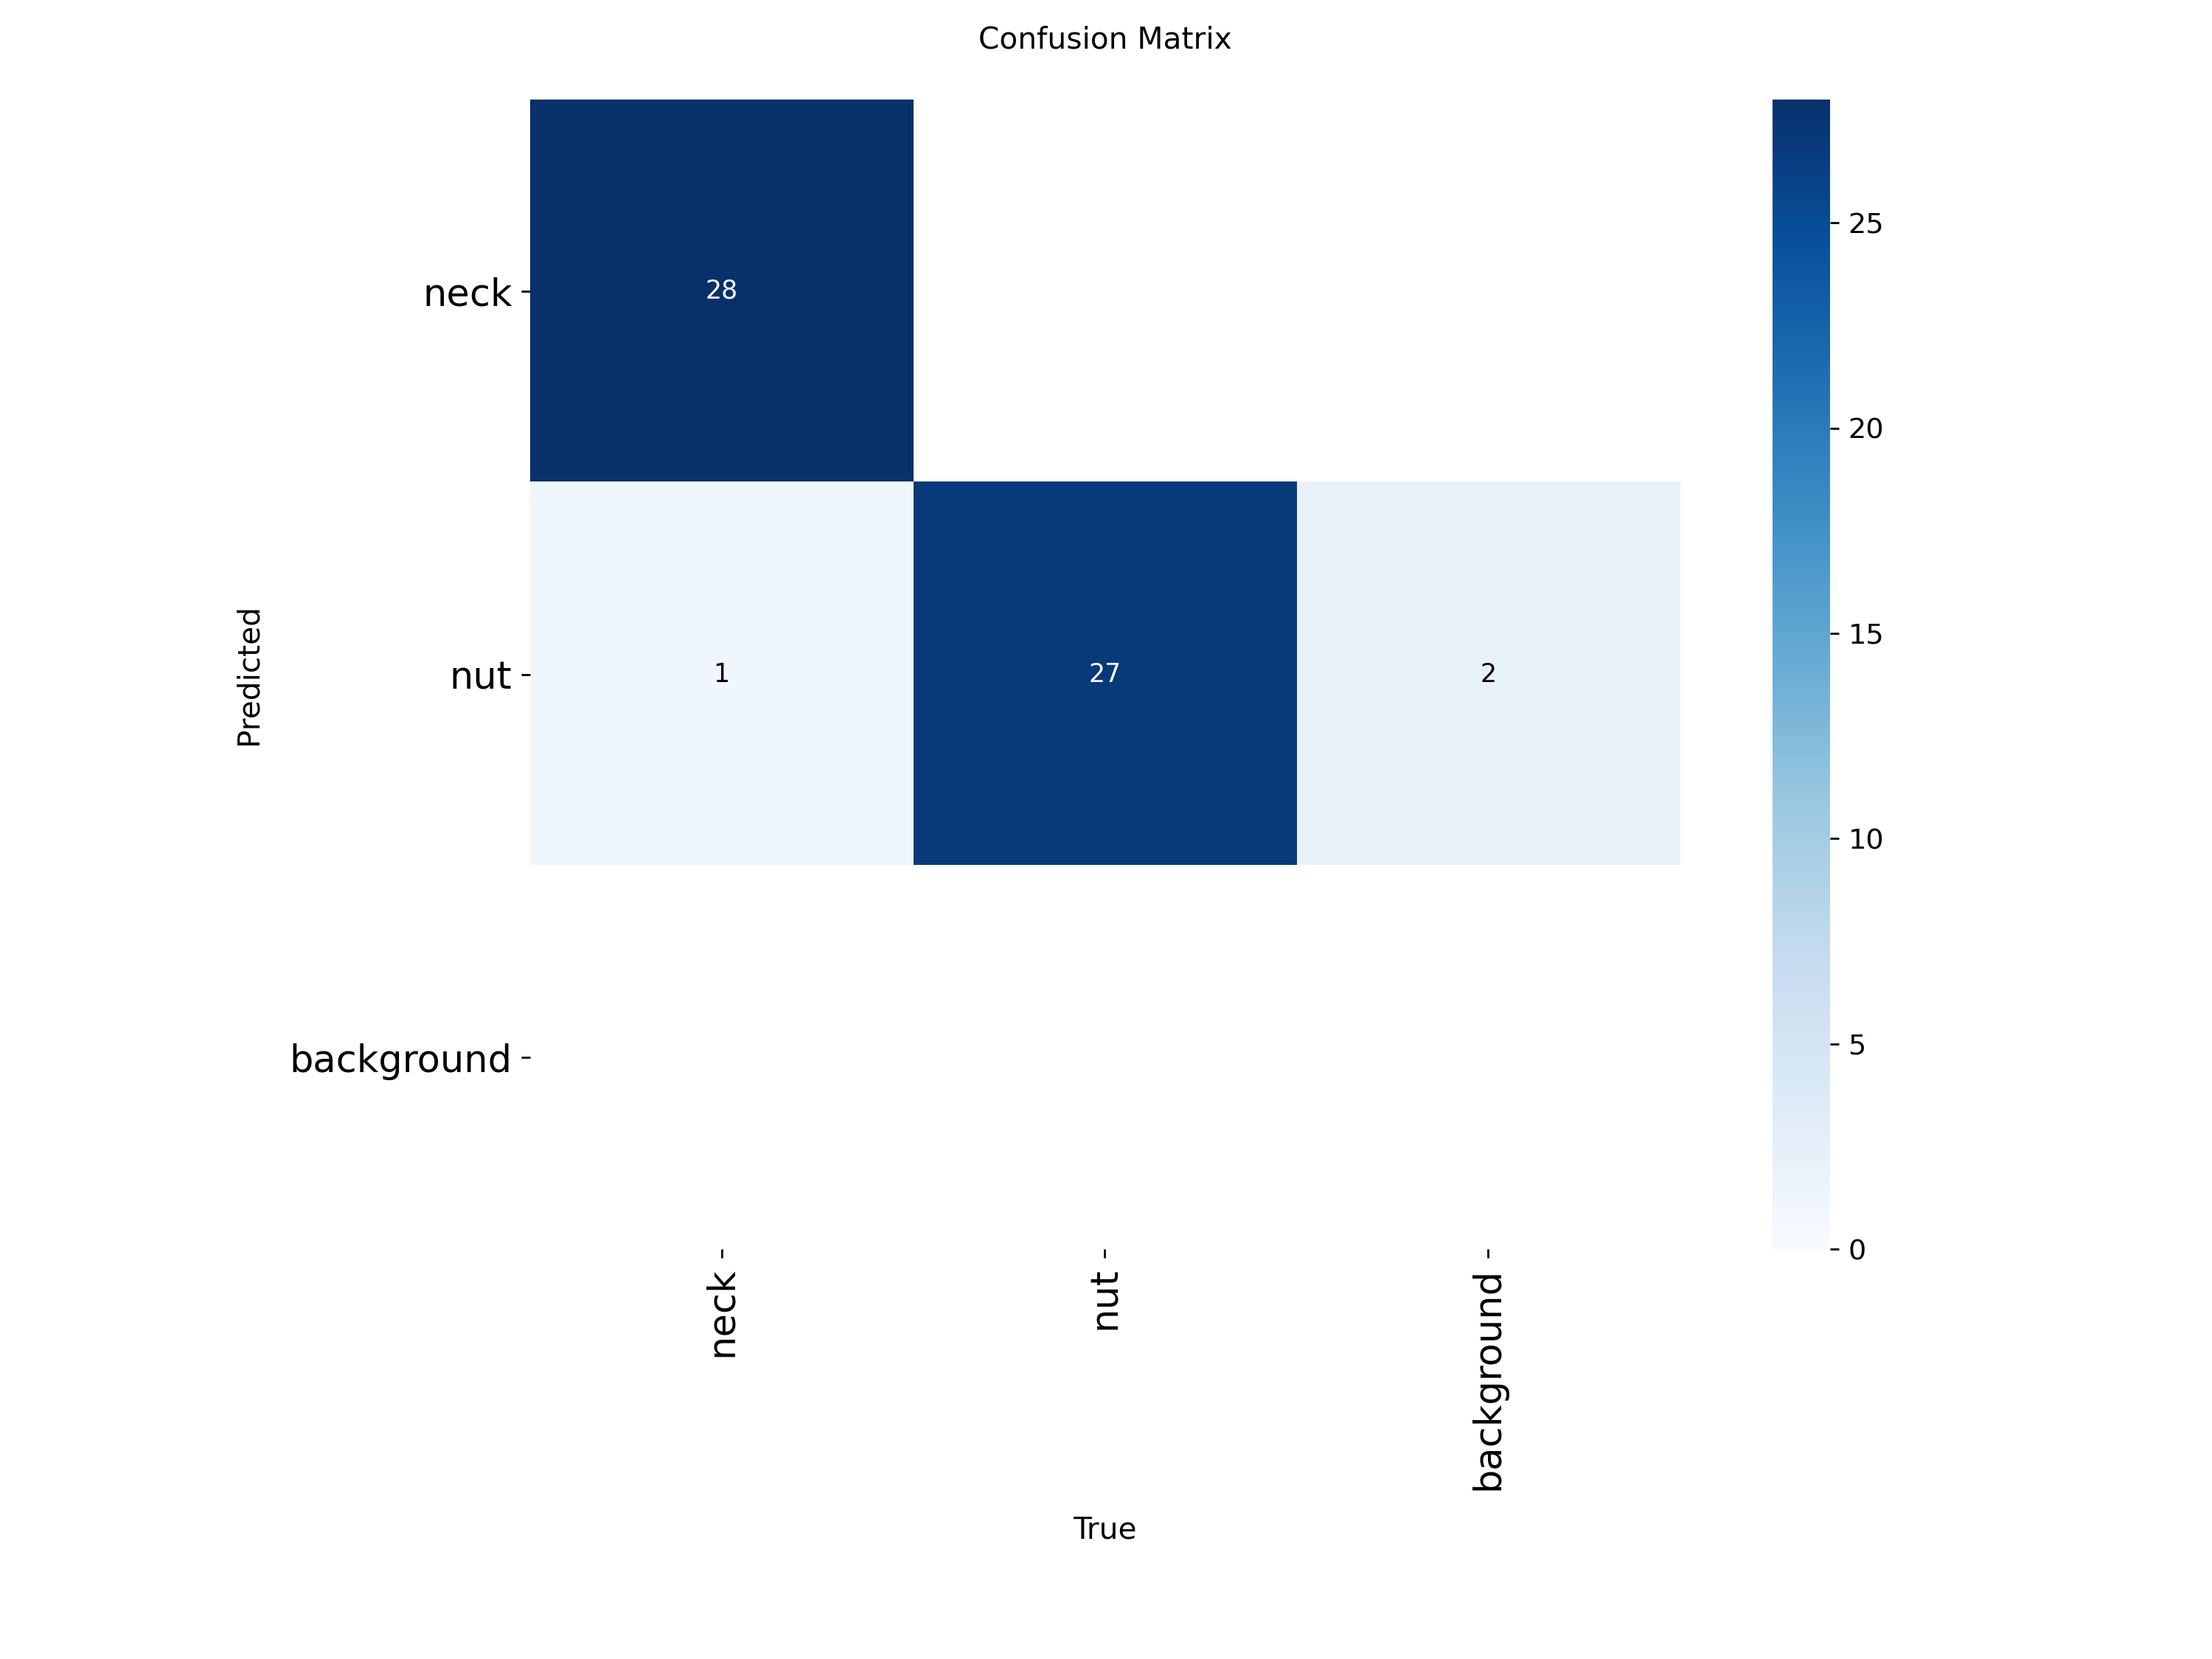

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path('/content/runs/guitar/seg_v1')

# 1. Читаємо метрики
results_csv = pd.read_csv(RUN_DIR / 'results.csv')
results_csv.columns = results_csv.columns.str.strip()  # прибираємо пробіли

print("=" * 60)
print("ФІНАЛЬНІ МЕТРИКИ")
print("=" * 60)
last = results_csv.iloc[-1]
print(f"Epoch: {int(last['epoch'])}")
print(f"Box mAP50: {last['metrics/mAP50(B)']:.3f}")
print(f"Box mAP50-95: {last['metrics/mAP50-95(B)']:.3f}")
print(f"Mask mAP50: {last['metrics/mAP50(M)']:.3f}  ← головна метрика")
print(f"Mask mAP50-95: {last['metrics/mAP50-95(M)']:.3f}")

# 2. Графіки
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0,0].plot(results_csv['epoch'], results_csv['train/box_loss'], label='train', linewidth=2)
axes[0,0].plot(results_csv['epoch'], results_csv['val/box_loss'], label='val', linewidth=2)
axes[0,0].set_title('Box Loss', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(results_csv['epoch'], results_csv['train/seg_loss'], label='train', linewidth=2)
axes[0,1].plot(results_csv['epoch'], results_csv['val/seg_loss'], label='val', linewidth=2)
axes[0,1].set_title('Segmentation Loss', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(results_csv['epoch'], results_csv['train/cls_loss'], label='train', linewidth=2)
axes[0,2].plot(results_csv['epoch'], results_csv['val/cls_loss'], label='val', linewidth=2)
axes[0,2].set_title('Classification Loss', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('Epoch'); axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# Metrics
axes[1,0].plot(results_csv['epoch'], results_csv['metrics/mAP50(B)'], label='Box', linewidth=2)
axes[1,0].plot(results_csv['epoch'], results_csv['metrics/mAP50(M)'], label='Mask', linewidth=2)
axes[1,0].set_title('mAP@0.5', fontsize=13, fontweight='bold')
axes[1,0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='target 0.8')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(results_csv['epoch'], results_csv['metrics/mAP50-95(B)'], label='Box', linewidth=2)
axes[1,1].plot(results_csv['epoch'], results_csv['metrics/mAP50-95(M)'], label='Mask', linewidth=2)
axes[1,1].set_title('mAP@0.5:0.95', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

axes[1,2].plot(results_csv['epoch'], results_csv['metrics/precision(M)'], label='Precision', linewidth=2)
axes[1,2].plot(results_csv['epoch'], results_csv['metrics/recall(M)'], label='Recall', linewidth=2)
axes[1,2].set_title('Precision / Recall (Mask)', fontsize=13, fontweight='bold')
axes[1,2].set_xlabel('Epoch'); axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Показуємо готові графіки від YOLO
from IPython.display import Image, display
print("\nАвтоматичні графіки YOLO:")
for name in ['results.png', 'confusion_matrix.png', 'PR_curve.png']:
    path = RUN_DIR / name
    if path.exists():
        print(f"\n{name}:")
        display(Image(str(path)))

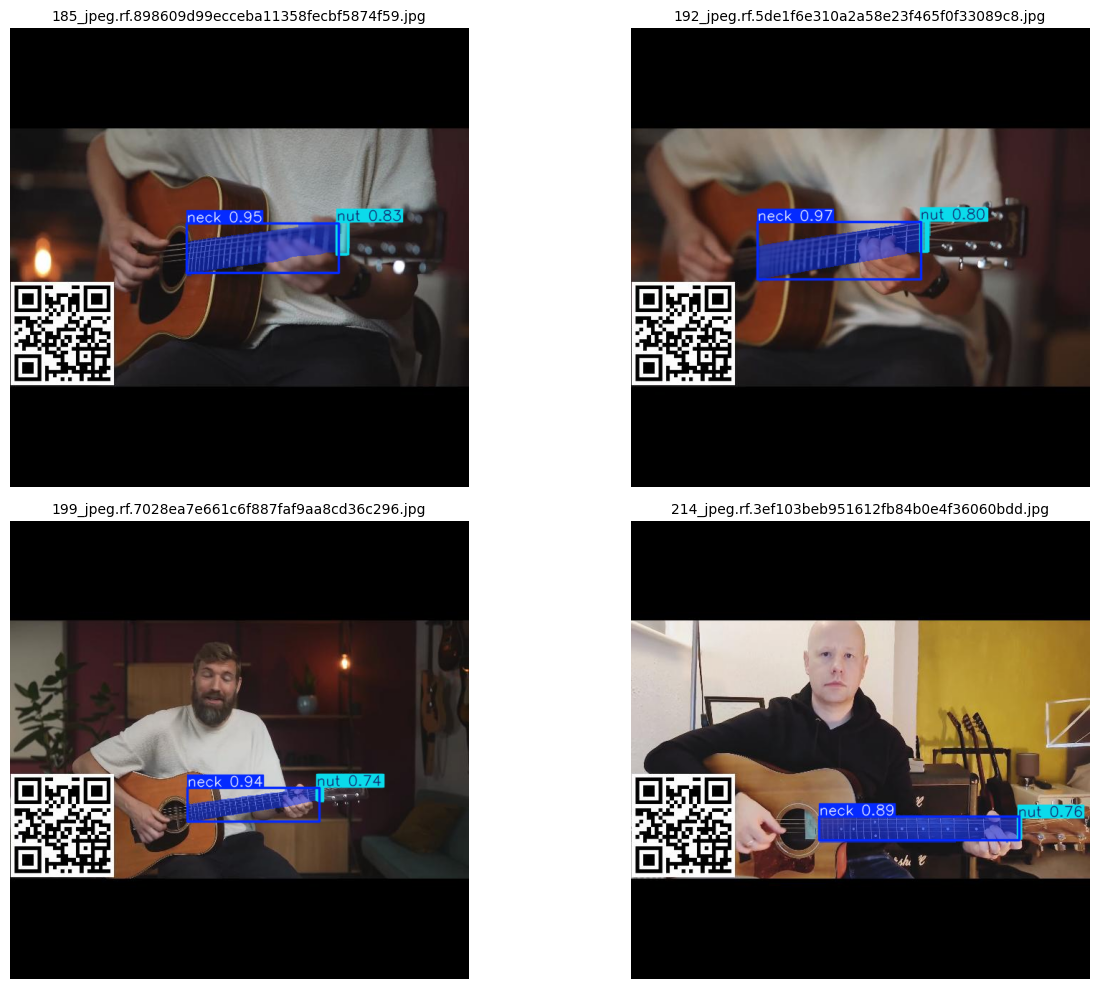

In [ ]:
from ultralytics import YOLO
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

BEST_MODEL = Path('/content/runs/guitar/seg_v1/weights/best.pt')
model = YOLO(str(BEST_MODEL))

# Тестуємо на кількох фото з test set
test_imgs = sorted((DATASET_PATH / 'test/images').glob('*'))[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, img_p in zip(axes.flat, test_imgs):
    results = model(str(img_p), conf=0.3, verbose=False)
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(img_p.name, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=100, bbox_inches='tight')
plt.show()